###Channel Gain Code-Outdoor

In [4]:
import numpy as np
import math

c = 3 * 10**8                                    # propagation velocity in the free space [m/s]
h_BS = 3.5                                       # antenna height of the base station [m]
h_UT = 3.5                                       # antenna height of the user terminal [m]
h_E = 1                                          # effective environment height [m]
h_prime_BS = h_BS - h_E                          # effective antenna height of the base station [m]
h_prime_UT = h_UT - h_E                          # effective antenna height of the user terminal [m]

def get_distance2D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)
    return d

def get_distance3D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2 + (p1[2] - p2[2]) ** 2)
    return d

def get_PL_LOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    d_BP = (4 * h_prime_BS * h_prime_UT * f_c) / c
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= d_BP):
            PL_LOS = 32.4 + 21*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
        elif (d_2D >= d_BP) and (d_2D <= 5 * 10**3):
            PL_LOS = 32.4 + 40*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9)) - 9.5*math.log10((d_BP)**2 + (p1[2] - p2[2])**2)
    return PL_LOS

def get_PL_NLOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_prime_NLOS = 17.3 + 38.3*math.log10(d_3D) + 24.9*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= 5 * 10**3):
            PL_prime_NLOS = 22.4 + 35.3*math.log10(d_3D) + 21.3*math.log10(f_c * 10**(-9)) - 0.3*(p2[2] - 1.5)
    PL_NLOS = max(get_PL_LOS(p1, p2, f_c), PL_prime_NLOS)
    return PL_NLOS

#this function gives the probability that how much of the transmission is in Line of Sight
def get_Pr(p1, p2):
    d_2D = get_distance2D(p1, p2)
    if (d_2D < 10):
        if (d_2D <= 1.2):
            pr_LOS = 1
        elif (d_2D > 1.2) and (d_2D < 6.5):
            pr_LOS = math.exp(-(d_2D - 1.2)/4.7)
        elif (d_2D >= 6.5):
            pr_LOS = math.exp(-(d_2D - 6.5)/32.6) * 0.32
    else:
        if d_2D <= 18:
            pr_LOS = 1
        elif d_2D > 18:
            pr_LOS = (18/d_2D) + (math.exp(-d_2D/36) * (1 - (18/d_2D)))
    return pr_LOS

def get_PL(p1, p2, f_c):
    PL = get_Pr(p1, p2) * get_PL_LOS(p1, p2, f_c) + (1 - get_Pr(p1, p2)) * get_PL_NLOS(p1, p2, f_c)
    return PL

def get_channel_gain(p1, p2, f_c):
    g = 1 / 10**(get_PL(p1, p2, f_c) / 10)
    return g

###Channel Gain Code-InH(Open/Mixed)

In [5]:
import numpy as np
import math

def get_distance2D(p1, p2):
    return np.hypot(p1[0]-p2[0], p1[1]-p2[1])

def get_distance3D(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

# -------- 38.901 InH (Indoor-Office) PATH LOSS --------
def get_PL_LOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office LOS:
      PL_LOS = 32.4 + 17.3*log10(d_3D) + 20*log10(fc_GHz), for 1 m <= d_3D <= 150 m
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:  # spec validity starts at 1 m
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20.0*math.log10(fc_GHz)
    return PL_LOS

def get_PL_NLOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office NLOS (use max with LOS):
      PL'_NLOS = 38.3*log10(d_3D) + 17.30*log10(fc_GHz) + 24.9, for 1 m <= d_3D <= 150 m
      PL_NLOS = max(PL_LOS, PL'_NLOS)
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = get_PL_LOS_InH(p1, p2, f_c)
    PLp_NLOS = 38.3*math.log10(d_3D) + 17.30*math.log10(fc_GHz) + 24.9
    return max(PL_LOS, PLp_NLOS)

# -------- LOS PROBABILITY (choose 'open' or 'mixed') --------
def get_Pr_InH(p1, p2, office_type='open'):
    """
    InH LOS probability from TR 38.901 Table 7.4.2-1.
    office_type: 'open' (default) or 'mixed'
    Uses d_in-2D (horizontal) in meters.
    """
    d = get_distance2D(p1, p2)
    if office_type == 'mixed':
        if d <= 1.2:
            return 1.0
        elif d < 6.5:
            return math.exp(-(d - 1.2)/4.7)
        else:
            return 0.32 * math.exp(-(d - 6.5)/32.6)
    else:  # 'open' office
        if d <= 5.0:
            return 1.0
        elif d < 49.0:
            return math.exp(-(d - 5.0)/70.0)
        else:
            return 0.54 * math.exp(-(d - 49.0)/211.7)

def get_PL_InH(p1, p2, f_c, office_type='open'):
    pr = get_Pr_InH(p1, p2, office_type)
    PL_los = get_PL_LOS_InH(p1, p2, f_c)
    PL_nlos = get_PL_NLOS_InH(p1, p2, f_c)
    return pr*PL_los + (1.0 - pr)*PL_nlos

def get_channel_gain_InH(p1, p2, f_c, office_type='open'):
    """
    Returns linear power gain g = 10^(-PL/10)
    """
    PL = get_PL_InH(p1, p2, f_c, office_type)
    return 10.0**(-PL/10.0)


###Computing C bound Function

In [6]:
import numpy as np

def compute_c_bounds(h, P, P_max, eta):
    """
    Compute the valid c range for the utility function.

    Args:
        h (np.ndarray): Channel gains, shape (N,)
        P (np.ndarray): Current powers, shape (N,)
        P_max (np.ndarray or float): Maximum power(s), shape (N,) or scalar
        eta (float): Noise scaling parameter

    Returns:
        (float, float): (c_lower, c_upper)
    """
    N = len(h)
    c_lowers = []
    c_uppers = []

    print("For number of transmitters: ",N)
    for n in range(N):
        # Exponential sum excluding n
        exp_sum = np.sum([np.abs(h[m]) * np.sqrt(P[m]) / np.sqrt(eta)
                          for m in range(N) if m != n])

        # Lower bound
        c_lower = (np.sqrt(eta) / (2 * np.sqrt(P_max[n]) * np.abs(h[n]))) * np.exp(exp_sum)

        # Upper bound
        c_upper = (np.sqrt(eta) / (np.abs(h[n]) * np.sqrt(P[n]))) * np.exp(exp_sum)

        c_lowers.append(c_lower)
        c_uppers.append(c_upper)

    # Feasible range = intersection
    c_lower_final = min(c_lowers)
    c_upper_final = max(c_uppers)

    return c_lower_final, c_upper_final

###Testing C bound Function

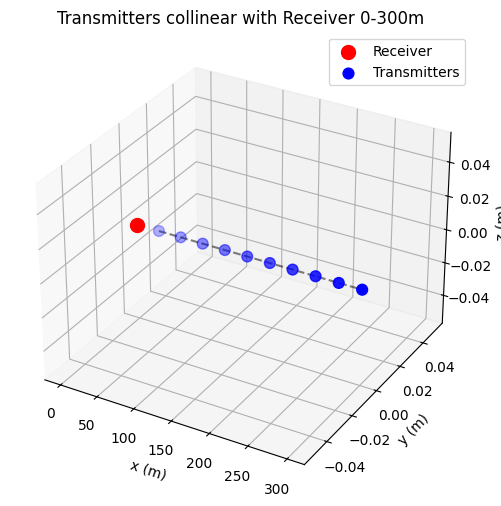

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N = 10
d_max = 300.0
max_iteration = 10
receiver_coordinates = (0.0, 0.0, 0.0)

# Transmitters equally spaced along x-axis between 0 and 300 m
x_positions = np.linspace(d_max/N, d_max, N)  # start after 0
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]


# ---- Plot 3D ----
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# Receiver
ax.scatter(*receiver_coordinates, c='red', s=100, label='Receiver')

# Transmitters
tx = np.array(transmitter_coordinates)
ax.scatter(tx[:,0], tx[:,1], tx[:,2], c='blue', s=60, label='Transmitters')

# Connect them along the line
ax.plot(tx[:,0], tx[:,1], tx[:,2], 'k--', alpha=0.5)

# Labels
ax.set_title("Transmitters collinear with Receiver 0-300m")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.legend()
ax.grid(True)

plt.show()


In [20]:
"""N = 10
max_iteration = 50
receiver_coordinates = (0, 0, 0)
transmitter_coordinates = [(7.5 + i*4.5, 3.0 + i*2.25, 2.25 + i*0.75) for i in range(N)]"""

d_max = 300.0
receiver_coordinates = (0.0, 0.0, 0.0)

# Transmitters equally spaced along x-axis between 0 and 300 m
x_positions = np.linspace(d_max/N, d_max, N)  # start after 0
transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

#h contains channel gains for both the 5 nodes
h = [0 for i in range(N)]
for i in range(N):
    h[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P = np.random.uniform(0.1, 1.0, N)              # current powers
P_max = np.ones(N)                       # max power = 1 for all
eta = 1.0

c_lower,c_upper = compute_c_bounds(h, P, P_max, eta)
print(c_lower)
print(c_upper)


For number of transmitters:  10
11914942.948256811
1103076717894.8093


###Utility Function and Optimal Power Function

In [21]:
import numpy as np
import pandas as pd
import numpy.typing as npt
from scipy.optimize import minimize

def utility_vector(P: npt.NDArray[np.float64], h: npt.NDArray[np.float64], c: np.float64, eta: np.float64):
    utilities = np.zeros(len(P))
    sum1 = np.sum(h * np.sqrt(P) / np.sqrt(eta))

    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        utilities[i] = me * np.exp(other) - c * np.power(me, 2)
    return utilities


def closed_form_p_star(h: npt.NDArray[np.float64], c: np.float64, eta: np.float64, P_max: npt.NDArray[np.float64]):
    # sum1 = np.sum(h * np.sqrt(P_max)/np.sqrt(eta))
    # P_star = np.zeros(len(P_max))
    # for i in range(len(P_max)):
    #     me = h[i] * np.sqrt(P_star[i]) / np.sqrt(eta)
    #     other = sum1 - me
    #     P_star[i] = eta * np.exp(2*other)/ (4 * np.power(c, 2) * np.power(h[i], 2))

    P_init = P_max.copy()
    P_star = minimize(lambda x: -utility_vector(x, h, c, eta), P_init, method='BFGS')
    P_star = np.clip(P_star, 0, P_max)
    return P_star

### Best Response Function

In [24]:
#Adaptive Best Response Function

import time
import numpy as np
import numpy.typing as npt
import pandas as pd

def adaptive_best_response(
    P: npt.NDArray[np.float64],
    h: npt.NDArray[np.float64],
    eta: np.float64,
    epsilon: np.float64,
    P_max: npt.NDArray[np.float64],
    max_iteration: int = 1000
):
    print('Executing adaptive best response')
    # Compute feasible bounds for c
    c_lower, c_upper = compute_c_bounds(h,P, P_max, eta)

    if c_lower >= c_upper:
        print("⚠ No feasible c interval found.")
        return None, {}, {}, None, None

    history_util = {}
    history_power = {}

    # Bisection search for best c
    while (c_upper - c_lower) > 1e-6:  # tolerance for c
        #here I have taken c manually
        c = 1.45569829e11
        #c = (c_lower + c_upper) / 2
        print(c)

        P_current = P.copy()
        utility_history = [utility_vector(P_current, h, c, eta)]
        power_history = [P_current.copy()]
        convergence = 0
        iteration = 0
        stop_due_to_negative = False
        stop_due_to_max = False

        # Start timing BRD iterations
        brd_start = time.time()

        while convergence == 0:
            iteration += 1

            P_new = P_current.copy()
            for i in range(len(P_new)):
                sum1 = np.sum(h * np.sqrt(P_new) / np.sqrt(eta))
                me = h[i] * np.sqrt(P_new[i]) / np.sqrt(eta)
                other = sum1 - me
                P_new[i] = eta * np.exp(2 * other) / (4 * np.power(c, 2) * np.power(h[i], 2))

            P_new = np.clip(P_new, 0, P_max)
            utility_history.append(utility_vector(P_new, h, c, eta))
            power_history.append(P_new.copy())

            if np.any(utility_history[-1] < 0):
                stop_due_to_negative = True
                break

            if np.all(P_new == P_max):
                stop_due_to_max = True
                break

            if iteration == max_iteration or np.all(np.abs(utility_history[-1] - utility_history[-2]) < epsilon):
                convergence = 1
            else:
                P_current = P_new

        # End timing
        brd_time = time.time() - brd_start

        history_util[c] = np.array(utility_history)
        history_power[c] = np.array(power_history)

        if not stop_due_to_negative and not stop_due_to_max:
            df = pd.DataFrame({
                "Node": np.arange(1, len(P) + 1),
                "Final Power P*": P_new,
                "Final Utility": utility_history[-1],
                "Channel Gain h": h
            })
            return c, history_util, history_power, df, brd_time

        # Update bounds for bisection
        if stop_due_to_negative or stop_due_to_max:
            print("c changed")
            c_lower = c
        else:
            print('c changed')
            c_upper = c

    return None, history_util, history_power, None, None

###Running/Testing the BRD

In [25]:
epsilon = np.float64(1e-70)
c_star, utility_histories, power_histories, df,brd_time = adaptive_best_response(
        P, h, eta, epsilon, P_max, max_iteration
    )

if c_star is not None:
        print("\n" + "="*80)
        print("FINAL RESULTS SUMMARY")
        print("="*80)
        pd.set_option('display.float_format', '{:.6e}'.format)
        print(df.to_string(index=False))
        print("="*80)

Executing adaptive best response
For number of transmitters:  10
145569829000.0

FINAL RESULTS SUMMARY
 Node  Final Power P*  Final Utility  Channel Gain h
    1    6.699481e-09   1.717389e-12    4.196411e-08
    2    2.533785e-06   1.717389e-12    2.157813e-09
    3    1.144318e-04   1.717389e-12    3.210889e-10
    4    1.579913e-03   1.717389e-12    8.641360e-11
    5    1.093508e-02   1.717389e-12    3.284638e-11
    6    4.960459e-02   1.717389e-12    1.542189e-11
    7    1.737968e-01   1.717389e-12    8.239062e-12
    8    5.148482e-01   1.717389e-12    4.786951e-12
    9    1.000000e+00   1.689540e-12    2.997389e-12
   10    1.000000e+00   1.411394e-12    1.984933e-12


###Plot 1: Power vs BR Iterations

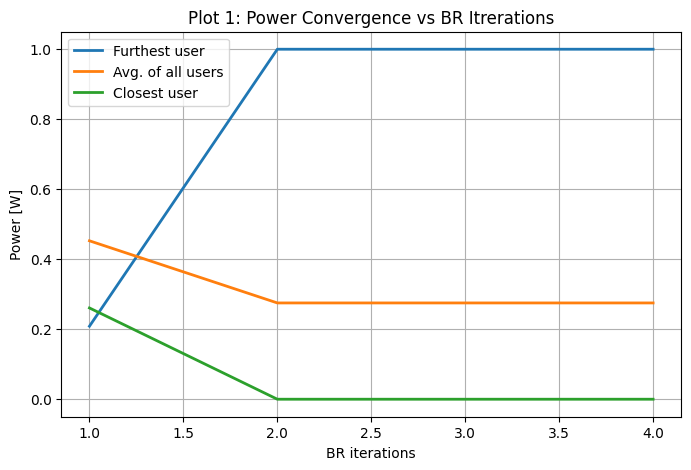

In [26]:
import matplotlib.pyplot as plt

if df is not None:
    # Pick the power history for the chosen c_star
    power_history = power_histories[c_star]  # shape = (iterations, N)

    # Closest user = highest channel gain
    closest_idx = np.argmax(h)
    # Furthest user = lowest channel gain
    furthest_idx = np.argmin(h)

    # Extract time series
    closest_user = power_history[:, closest_idx]
    furthest_user = power_history[:, furthest_idx]
    avg_users = np.mean(power_history, axis=1)

    iterations = np.arange(1, power_history.shape[0] + 1)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(iterations, furthest_user, label="Furthest user", linewidth=2)
    plt.plot(iterations, avg_users, label="Avg. of all users", linewidth=2)
    plt.plot(iterations, closest_user, label="Closest user", linewidth=2)

    plt.xlabel("BR iterations")
    plt.ylabel("Power [W]")
    plt.title("Plot 1: Power Convergence vs BR Itrerations")
    plt.legend()
    plt.grid(True)
    plt.show()

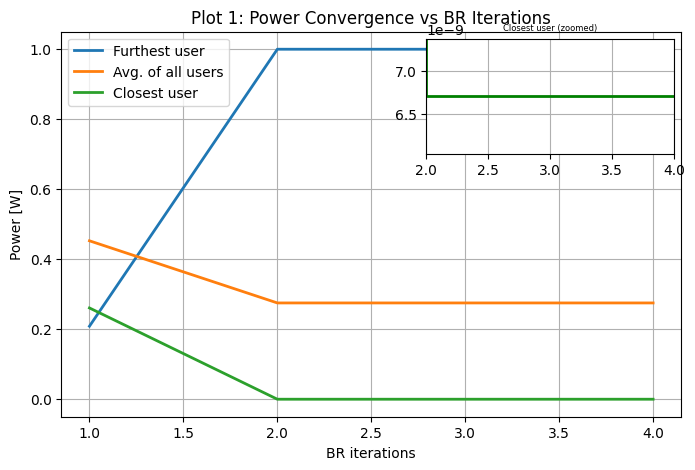

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

if df is not None:
    power_history = power_histories[c_star]  # shape = (iterations, N)
    closest_idx = np.argmax(h)
    furthest_idx = np.argmin(h)

    closest_user = power_history[:, closest_idx]
    furthest_user = power_history[:, furthest_idx]
    avg_users = np.mean(power_history, axis=1)
    iterations = np.arange(1, power_history.shape[0] + 1)

    # Main plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, furthest_user, label="Furthest user", linewidth=2)
    ax.plot(iterations, avg_users, label="Avg. of all users", linewidth=2)
    ax.plot(iterations, closest_user, label="Closest user", linewidth=2)

    ax.set_xlabel("BR iterations")
    ax.set_ylabel("Power [W]")
    ax.set_title("Plot 1: Power Convergence vs BR Iterations")
    ax.legend()
    ax.grid(True)

    # Inset focusing on the 'flat' part of closest user (iterations 2 → 4)
    axins = inset_axes(ax, width="40%", height="30%", loc="upper right")  # moved here
    axins.plot(iterations, closest_user, color="green", linewidth=2)
    axins.set_title("Closest user (zoomed)", fontsize=6)

    # Zoom on iterations 2–4 and y-range around the small values
    axins.set_xlim(2, 4)
    axins.set_ylim(min(closest_user[1:]) * 0.9, max(closest_user[1:]) * 1.1)
    axins.grid(True)

    plt.show()


###Plot 2: Utility vs BR Iterations

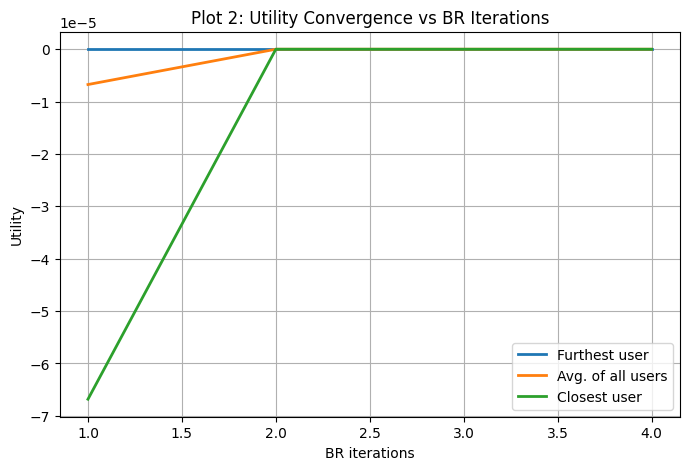

In [32]:
import matplotlib.pyplot as plt

# Pick the utility history for the chosen c
util_history = utility_histories[c_star]  # shape = (iterations, N)

# Closest and furthest users (same indices as before)
closest_idx = np.argmax(h)
furthest_idx = np.argmin(h)

# Extract time series
closest_util = util_history[:, closest_idx]
furthest_util = util_history[:, furthest_idx]
avg_util = np.mean(util_history, axis=1)

iterations = np.arange(1, util_history.shape[0] + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(iterations, furthest_util, label="Furthest user", linewidth=2)
plt.plot(iterations, avg_util, label="Avg. of all users", linewidth=2)
plt.plot(iterations, closest_util, label="Closest user", linewidth=2)

plt.xlabel("BR iterations")
plt.ylabel("Utility")
plt.title("Plot 2: Utility Convergence vs BR Iterations")
plt.legend()
plt.grid(True)
plt.show()

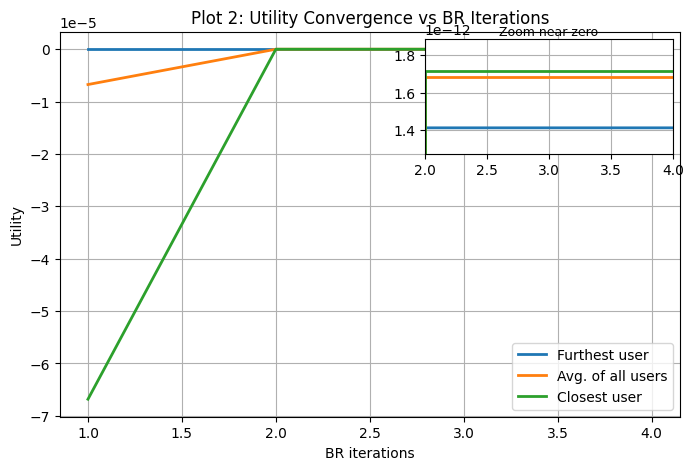

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Pick the utility history for the chosen c
util_history = utility_histories[c_star]  # shape = (iterations, N)

closest_idx = np.argmax(h)
furthest_idx = np.argmin(h)

closest_util = util_history[:, closest_idx]
furthest_util = util_history[:, furthest_idx]
avg_util = np.mean(util_history, axis=1)

iterations = np.arange(1, util_history.shape[0] + 1)

# Main plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iterations, furthest_util, label="Furthest user", linewidth=2)
ax.plot(iterations, avg_util, label="Avg. of all users", linewidth=2)
ax.plot(iterations, closest_util, label="Closest user", linewidth=2)

ax.set_xlabel("BR iterations")
ax.set_ylabel("Utility")
ax.set_title("Plot 2: Utility Convergence vs BR Iterations")
ax.legend()
ax.grid(True)

# Inset: zoom only on the flat region (iterations 2 → 4)
axins = inset_axes(ax, width="40%", height="30%", loc="upper right")
axins.plot(iterations, furthest_util, linewidth=2)
axins.plot(iterations, avg_util, linewidth=2)
axins.plot(iterations, closest_util, linewidth=2)
axins.set_title("Zoom near zero", fontsize=9, pad=2)

# Focus on iterations 2–4
axins.set_xlim(2, 4)

# Tighten y-limits just for this region
flat_values = np.concatenate([
    furthest_util[1:],  # from iteration 2
    avg_util[1:],
    closest_util[1:]
])
axins.set_ylim(min(flat_values) * 0.9, max(flat_values) * 1.1)
axins.grid(True)

plt.show()


###Plot 3: Optimal Power Allocation vs Users

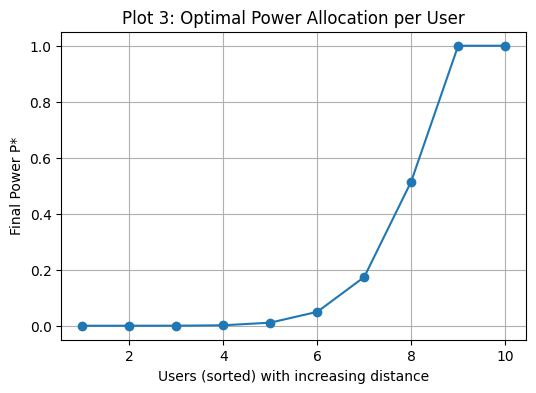

In [37]:
import matplotlib.pyplot as plt

# Sort users by index (or by distance if you have that column)
users = range(1, len(df) + 1)
power = df["Final Power P*"].values

plt.figure(figsize=(6,4))
plt.plot(users, power, marker='o')
plt.xlabel("Users (sorted) with increasing distance")
plt.ylabel("Final Power P*")
plt.title("Plot 3: Optimal Power Allocation per User")
plt.grid(True)
plt.show()

###Plot 4: Final Utility per User

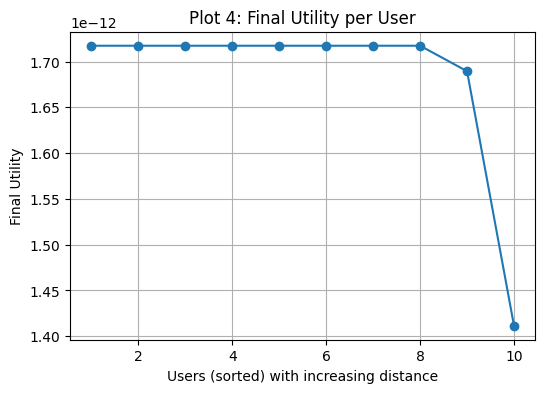

In [38]:
import matplotlib.pyplot as plt

# Sort users by index (or by distance if you have that column)
users = range(1, len(df) + 1)
power = df["Final Utility"].values

plt.figure(figsize=(6,4))
plt.plot(users, power, marker='o')
plt.xlabel("Users (sorted) with increasing distance")
plt.ylabel("Final Utility")
plt.title("Plot 4: Final Utility per User")
plt.grid(True)
plt.show()

###Plot 5: Mean Power vs No.of Users

Executing adaptive best response
For number of transmitters:  5
145569829000.0
Executing adaptive best response
For number of transmitters:  6
145569829000.0
Executing adaptive best response
For number of transmitters:  7
145569829000.0
Executing adaptive best response
For number of transmitters:  8
145569829000.0
Executing adaptive best response
For number of transmitters:  9
145569829000.0
Executing adaptive best response
For number of transmitters:  10
145569829000.0
Executing adaptive best response
For number of transmitters:  11
145569829000.0
Executing adaptive best response
For number of transmitters:  12
145569829000.0
Executing adaptive best response
For number of transmitters:  13
145569829000.0
Executing adaptive best response
For number of transmitters:  14
145569829000.0
Executing adaptive best response
For number of transmitters:  15
145569829000.0
Executing adaptive best response
For number of transmitters:  16
145569829000.0
Executing adaptive best response
For number o

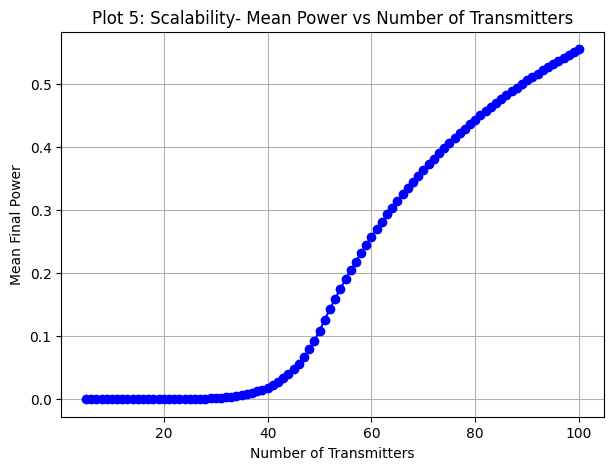

In [39]:
results = []

# Loop over number of transmitters
for i in range(5, 101):   # 1 to 100
    # Initialize inputs for n transmitters
    receiver_coordinates = (0, 0, 0)
    transmitter_coordinates = [(7.5 + j*4.5, 3.0 + j*2.25, 2.25 + j*0.75) for j in range(i)]

    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(0,i)]
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    P = np.random.uniform(0.1, 1.0, i)              # current powers
    P_max = np.ones(i)                       # max power = 1
    eta = 1.0


    # Run your algorithm
    *_, df, _ = adaptive_best_response(P, h, eta, epsilon, P_max, max_iteration)

    # Extract final powers (example: mean power across transmitters)
    if df is not None:
        mean_power = df['Final Power P*'].mean()

        # Save (n, mean_power) pair
        results.append((i, mean_power))

# Convert to DataFrame for plotting
scalability_df = pd.DataFrame(results, columns=['Users', 'Mean Power'])

plt.figure(figsize=(7,5))
plt.plot(scalability_df['Users'], scalability_df['Mean Power'], marker='o', color='blue')
plt.xlabel("Number of Transmitters")
plt.ylabel("Mean Final Power")
plt.title("Plot 5: Scalability- Mean Power vs Number of Transmitters")
plt.grid(True)
plt.show()

###Plot 6: Mean Utility vs No.of Users

Executing adaptive best response
For number of transmitters:  5
145569829000.0
Executing adaptive best response
For number of transmitters:  6
145569829000.0
Executing adaptive best response
For number of transmitters:  7
145569829000.0
Executing adaptive best response
For number of transmitters:  8
145569829000.0
Executing adaptive best response
For number of transmitters:  9
145569829000.0
Executing adaptive best response
For number of transmitters:  10
145569829000.0
Executing adaptive best response
For number of transmitters:  11
145569829000.0
Executing adaptive best response
For number of transmitters:  12
145569829000.0
Executing adaptive best response
For number of transmitters:  13
145569829000.0
Executing adaptive best response
For number of transmitters:  14
145569829000.0
Executing adaptive best response
For number of transmitters:  15
145569829000.0
Executing adaptive best response
For number of transmitters:  16
145569829000.0
Executing adaptive best response
For number o

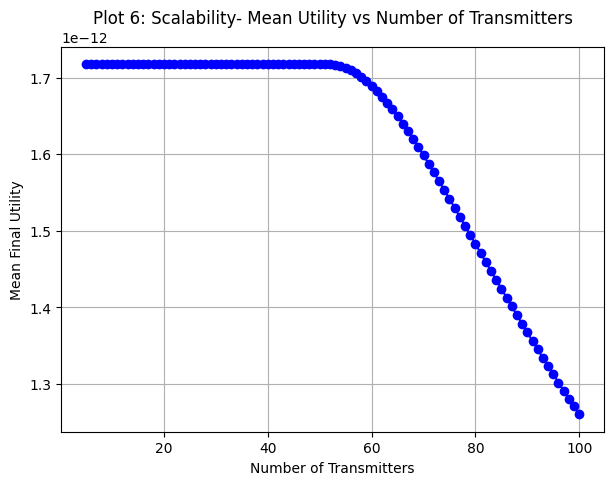

In [40]:
results = []

# Loop over number of transmitters
for i in range(5, 101):   # 1 to 100
    # Initialize inputs for n transmitters
    receiver_coordinates = (0, 0, 0)
    transmitter_coordinates = [(7.5 + j*4.5, 3.0 + j*2.25, 2.25 + j*0.75) for j in range(i)]

    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(0,i)]
    for j in range(0,i):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)

    P = np.random.uniform(0.1, 1.0, i)              # current powers
    P_max = np.ones(i)                       # max power = 1
    eta = 1.0


    # Run your algorithm
    *_, df, _ = adaptive_best_response(P, h, eta, epsilon, P_max, max_iteration)

    # Extract final powers (example: mean power across transmitters)
    if df is not None:
        mean_utility = df['Final Utility'].mean()

        # Save (n, mean_power) pair
        results.append((i, mean_utility))


# Convert to DataFrame for plotting
scalability_df1 = pd.DataFrame(results, columns=['Users', 'Mean Utility'])

plt.figure(figsize=(7,5))
plt.plot(scalability_df1['Users'], scalability_df1['Mean Utility'], marker='o', color='blue')
plt.xlabel("Number of Transmitters")
plt.ylabel("Mean Final Utility")
plt.title("Plot 6: Scalability- Mean Utility vs Number of Transmitters")
plt.grid(True)
plt.show()

### PLOT 7: USERS VS TIME FOR BRD

Executing adaptive best response
For number of transmitters:  5
145569829000.0
Executing adaptive best response
For number of transmitters:  6
145569829000.0
Executing adaptive best response
For number of transmitters:  7
145569829000.0
Executing adaptive best response
For number of transmitters:  8
145569829000.0
Executing adaptive best response
For number of transmitters:  9
145569829000.0
Executing adaptive best response
For number of transmitters:  10
145569829000.0
Executing adaptive best response
For number of transmitters:  11
145569829000.0
Executing adaptive best response
For number of transmitters:  12
145569829000.0
Executing adaptive best response
For number of transmitters:  13
145569829000.0
Executing adaptive best response
For number of transmitters:  14
145569829000.0
Executing adaptive best response
For number of transmitters:  15
145569829000.0
Executing adaptive best response
For number of transmitters:  16
145569829000.0
Executing adaptive best response
For number o

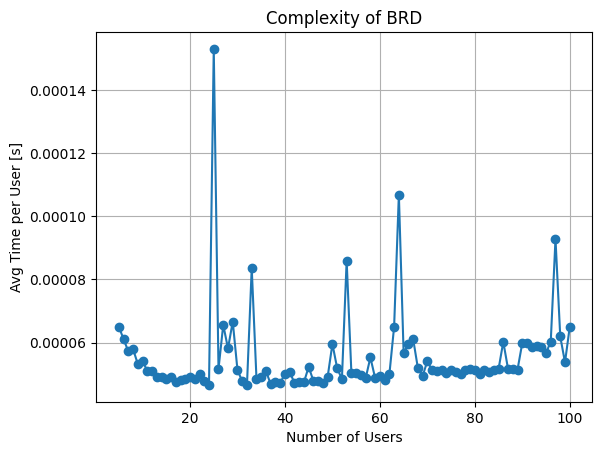

In [41]:
results = []

for n in range(5, 101, 1):  # test with 10,20,...,100 users
    P = np.random.uniform(0.1, 1.0, n)
    P_max = np.ones(n)
    receiver_coordinates = (0, 0, 0)
    transmitter_coordinates = [(7.5 + i*4.5, 3.0 + i*2.25, 2.25 + i*0.75) for i in range(n)]

    #h contains channel gains for both the 5 nodes
    h = [0 for i in range(n)]
    for i in range(n):
        h[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

    _, _, _, df, brd_time = adaptive_best_response(P, h, eta=1.0, epsilon=1e-3, P_max=P_max, max_iteration=100)

    if brd_time is not None:
        avg_time_per_user = brd_time / n
        results.append((n, avg_time_per_user))

# Plot
scalability_df = pd.DataFrame(results, columns=['Users', 'Avg BRD Time'])
plt.plot(scalability_df['Users'], scalability_df['Avg BRD Time'], marker='o')
plt.xlabel("Number of Users")
plt.ylabel("Avg Time per User [s]")
plt.title("Complexity of BRD")
plt.grid(True)
plt.show()


###COMPARISON FOR MSE SOLN VS CENTRALISED VS OUR SOLN

In [43]:
from scipy.optimize import minimize

def centralized_solution(h, eta, c, P_max):
    n = len(h)

    # Objective: maximize sum of utilities
    def objective(P):
        return -np.sum(utility_vector(P, h, c, eta))  # negative for minimization

    # Bounds: 0 <= P_i <= P_max[i]
    bounds = [(0, P_max[i]) for i in range(n)]

    # Initial guess: half of max power
    P0 = np.array(P_max) / 2

    res = minimize(objective, P0, bounds=bounds, method="L-BFGS-B")

    return res.x  # optimal power allocation


Executing adaptive best response
For number of transmitters:  5
145569829000.0
Executing adaptive best response
For number of transmitters:  6
145569829000.0
Executing adaptive best response
For number of transmitters:  7
145569829000.0
Executing adaptive best response
For number of transmitters:  8
145569829000.0
Executing adaptive best response
For number of transmitters:  9
145569829000.0
Executing adaptive best response
For number of transmitters:  10
145569829000.0
Executing adaptive best response
For number of transmitters:  11
145569829000.0
Executing adaptive best response
For number of transmitters:  12
145569829000.0
Executing adaptive best response
For number of transmitters:  13
145569829000.0
Executing adaptive best response
For number of transmitters:  14
145569829000.0
Executing adaptive best response
For number of transmitters:  15
145569829000.0
Executing adaptive best response
For number of transmitters:  16
145569829000.0
Executing adaptive best response
For number o

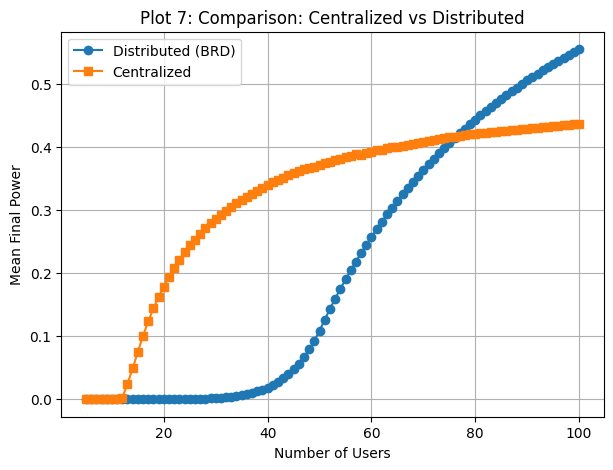

In [44]:
import matplotlib.pyplot as plt

brd_means = []
central_means = []
users = range(5, 101, 1)

for n in users:
    receiver_coordinates = (0, 0, 0)
    transmitter_coordinates = [(7.5 + j*4.5, 3.0 + j*2.25, 2.25 + j*0.75) for j in range(n)]

    #h contains channel gains for both the 5 nodes
    h = [0 for j in range(0,n)]
    for j in range(0,n):
        h[j] = get_channel_gain(transmitter_coordinates[j],receiver_coordinates,2405*10**6)
    P = np.random.uniform(0.1, 1.0, n)
    P_max = np.ones(n)
    eta = 1.0

    # --- Distributed (your BRD) ---
    c_star, _, _, df, _ = adaptive_best_response(P, h, eta, epsilon, P_max, max_iteration)
    if df is None:
        continue
    brd_means.append(df['Final Power P*'].mean())

    # --- Centralized ---
    P_central = centralized_solution(h, eta, c_star, P_max)
    central_means.append(np.mean(P_central))

# --- Plot comparison ---
plt.figure(figsize=(7,5))
plt.plot(users[:len(brd_means)], brd_means, marker='o', label="Distributed (BRD)")
plt.plot(users[:len(central_means)], central_means, marker='s', label="Centralized")
plt.xlabel("Number of Users")
plt.ylabel("Mean Final Power")
plt.title("Plot 7: Comparison: Centralized vs Distributed")
plt.legend()
plt.grid(True)
plt.show()

###Finding Powers for Indoor Scenario: for Plotting difference in Power(Indoor vs Outdoor)

In [45]:
import numpy as np
import math

N = 100
max_iteration = 50
receiver_coordinates = np.array((0, 0, 0))
transmitter_coordinates = np.array([(7.5 + i*4.5, 3.0 + i*2.25, 2.25 + i*0.75) for i in range(N)])

#h contains channel gains for both the 5 nodes
h_outdoor = [0 for i in range(N)]
for i in range(N):
    h_outdoor[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P = np.random.uniform(0.1, 1.0, N)              # current powers
P_max = np.ones(N)                       # max power = 1 for all
eta = 1.0

In [46]:
epsilon = np.float64(1e-70)
c_star, utility_histories, power_histories, df_outdoor,brd_time = adaptive_best_response(
        P, h_outdoor, eta, epsilon, P_max, max_iteration
    )

Executing adaptive best response
For number of transmitters:  100
145569829000.0


In [47]:
import numpy as np
import math

N = 100
max_iteration = 50
receiver_coordinates = np.array((0, 0, 0))
transmitter_coordinates = np.array([(7.5 + i*4.5, 3.0 + i*2.25, 2.25 + i*0.75) for i in range(N)])

#h contains channel gains for both the 5 nodes
h_indoor = [0 for i in range(N)]
for i in range(N):
    h_indoor[i] = get_channel_gain_InH(transmitter_coordinates[i],receiver_coordinates,2405*10**6)

P = np.random.uniform(0.1, 1.0, N)              # current powers
P_max = np.ones(N)                       # max power = 1 for all
eta = 1.0

In [48]:
epsilon = np.float64(1e-70)
c_star, utility_histories, power_histories, df_indoor,brd_time = adaptive_best_response(
        P, h_indoor, eta, epsilon, P_max, max_iteration
    )

Executing adaptive best response
For number of transmitters:  100
145569829000.0


100
100


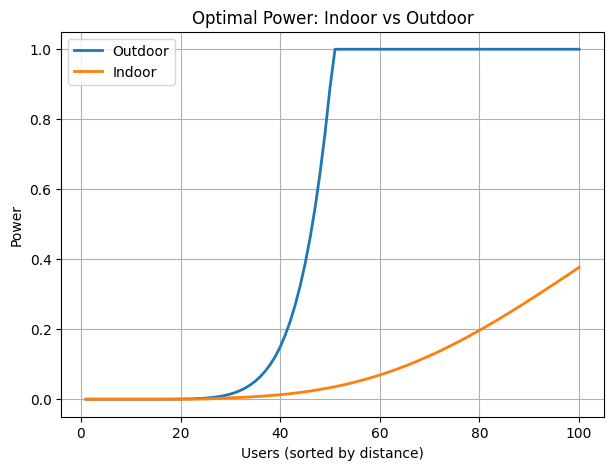

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Example arrays (replace these with your real values)
# sorted over the same set of users/distances
power_indoor = df_indoor['Final Power P*']   # your computed indoor power values
print(len(power_indoor))
power_outdoor = df_outdoor['Final Power P*']  # your computed outdoor power values
print(len(power_outdoor))

users = np.arange(1, len(power_indoor)+1)  # x-axis: user index (sorted)

plt.figure(figsize=(7,5))
plt.plot(users, power_outdoor, label="Outdoor", linewidth=2)
plt.plot(users, power_indoor, label="Indoor", linewidth=2)
plt.xlabel("Users (sorted by distance)")
plt.ylabel("Power")
plt.title("Optimal Power: Indoor vs Outdoor")
plt.grid(True)
plt.legend()
plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# replace these with your real arrays
power_indoor = np.array(power_indoor)   # your computed indoor power values
power_outdoor = np.array(power_outdoor) # your computed outdoor power values
distances = [get_distance3D(receiver_coordinates, ut) for ut in transmitter_coordinates]         # distances of the same users (unsorted)
# if you don't have distances, compute them from user coords, e.g. distances = np.linalg.norm(UT_positions - BS_position, axis=1)

# 1) Basic checks
print("Lengths:", len(power_indoor), len(power_outdoor), len(distances))
print("Indoor min/mean/max:", power_indoor.min(), power_indoor.mean(), power_indoor.max())
print("Outdoor min/mean/max:", power_outdoor.min(), power_outdoor.mean(), power_outdoor.max())

# 2) Check for clipping (e.g., capped at 1.0)
for name, arr in [("indoor", power_indoor), ("outdoor", power_outdoor)]:
    unique_caps = np.unique(arr[np.isclose(arr, arr.max())])
    print(name, "max value:", arr.max(), "count at max:", np.sum(np.isclose(arr, arr.max())))

# 3) Are you sure both arrays are for the same ordering?
#    Sort indices by distance and reorder both power arrays the same way:
idx = np.argsort(distances)  # ascending distance
p_indoor_sorted_by_distance = power_indoor[idx]
p_outdoor_sorted_by_distance = power_outdoor[idx]

# Print a small table for first/last few users to compare
print("\nFirst 10 users (closest):")
for i in range(min(10, len(idx))):
    j = idx[i]
    print(f"user {j}: dist={distances[j]:.2f}, indoor={power_indoor[j]:.4g}, outdoor={power_outdoor[j]:.4g}")

print("\nLast 10 users (farthest):")
for i in range(1, min(11, len(idx)+1)):
    j = idx[-i]
    print(f"user {j}: dist={distances[j]:.2f}, indoor={power_indoor[j]:.4g}, outdoor={power_outdoor[j]:.4g}")

# 4) Replot using same distance ordering (recommended)
plt.figure(figsize=(8,5))
plt.plot(distances[idx], p_outdoor_sorted_by_distance, label='Outdoor (sorted by distance)', linewidth=2)
plt.plot(distances[idx], p_indoor_sorted_by_distance,  label='Indoor (sorted by distance)', linewidth=2)
plt.xlabel('Distance (m)')
plt.ylabel('Power')
plt.title('Optimal Power vs Distance (both sorted by same distances)')
plt.legend()
plt.grid(True)
plt.show()

# 5) If you use indices rather than distances, ensure you sort both arrays the same way:
#    users_sorted_idx = np.argsort(distances)  # same as idx above
#    then plot users 1..N on x with p_indoor[users_sorted_idx] and p_outdoor[users_sorted_idx]


Lengths: 100 100 100
Indoor min/mean/max: 2.317899246354893e-12 0.09224566134138977 0.3767650713564554
Outdoor min/mean/max: 1.3433560267391864e-11 0.5543132209105296 1.0
indoor max value: 0.3767650713564554 count at max: 1
outdoor max value: 1.0 count at max: 50

First 10 users (closest):
user 0: dist=8.39, indoor=2.318e-12, outdoor=1.343e-11
user 1: dist=13.44, indoor=2.049e-11, outdoor=6.534e-11
user 2: dist=18.51, indoor=1.202e-10, outdoor=2.536e-10
user 3: dist=23.59, indoor=5.662e-10, outdoor=1.161e-09
user 4: dist=28.67, indoor=2.31e-09, outdoor=4.567e-09
user 5: dist=33.75, indoor=8.461e-09, outdoor=1.59e-08
user 6: dist=38.83, indoor=2.841e-08, outdoor=4.988e-08
user 7: dist=43.92, indoor=8.853e-08, outdoor=1.428e-07
user 8: dist=49.00, indoor=2.584e-07, outdoor=3.767e-07
user 9: dist=54.09, indoor=4.983e-07, outdoor=9.24e-07

Last 10 users (farthest):
user 99: dist=511.88, indoor=0.3768, outdoor=1
user 98: dist=506.80, indoor=0.3672, outdoor=1
user 97: dist=501.71, indoor=0.3

TypeError: only integer scalar arrays can be converted to a scalar index

<Figure size 800x500 with 0 Axes>

In [ ]:
import numpy as np

# ---- Frequency ----
f_c = 2405e6  # Hz

# ---- BS/UT positions (same for both scenarios) ----
h_BS, h_UT = 3.5, 1.5
BS_pos = [0, 0, h_BS]

def UT_pos(d): return [d, 0, h_UT]

# ---- Outdoor PL ----
def PL_outdoor(p1, p2, f_c):
    return get_PL(p1, p2, f_c)  # use your existing function

# ---- Indoor PL ----
def PL_indoor(p1, p2, f_c):
    return get_PL_InH(p1, p2, f_c)  # or 'mixed'

# ---- Compare at a few distances ----
distances = [5, 10, 20, 50, 100,1000]  # meters
print(f"{'Dist (m)':>8} | {'PL_in (dB)':>12} | {'PL_out (dB)':>12}")
print("-"*40)

for d in distances:
    p_UT = UT_pos(d)
    pl_in = PL_indoor(BS_pos, p_UT, f_c)
    pl_out = PL_outdoor(BS_pos, p_UT, f_c)
    print(f"{d:8.2f} | {pl_in:12.2f} | {pl_out:12.2f}")


In [ ]:
import numpy as np

# ---- Frequency ----
f_c = 2405e6  # Hz

# ---- BS/UT positions (same for both scenarios) ----
h_BS, h_UT = 3.5, 1.5
BS_pos = [0, 0, h_BS]

def UT_pos(d): return [d, 0, h_UT]

# ---- Outdoor PL ----
def PL_outdoor(p1, p2, f_c):
    return get_PL_NLOS(p1, p2, f_c)  # use your existing function

# ---- Indoor PL ----
def PL_indoor(p1, p2, f_c):
    return get_PL_NLOS_InH(p1, p2, f_c)  # or 'mixed'

# ---- Compare at a few distances ----
distances = [5, 10, 20, 50, 100,1000]  # meters
print(f"{'Dist (m)':>8} | {'PL_in_NLOS (dB)':>12} | {'PL_out_NLOS (dB)':>12}")
print("-"*40)

for d in distances:
    p_UT = UT_pos(d)
    pl_in = PL_indoor(BS_pos, p_UT, f_c)
    pl_out = PL_outdoor(BS_pos, p_UT, f_c)
    print(f"{d:8.2f} | {pl_in:12.2f} | {pl_out:12.2f}")
